## Region Proposals with CNN (R-CNN)

The one and only object detection algorithm which propose to select large number of regions from an image. 

Now, these regions are being passed to CNN architecture to predict the bounding boxes and class.

### **How to generate category independent Region proposals.**

Many papers are present for this like : objectness [1], selective search [39],
category-independent object proposals [14], constrained
parametric min-cuts (CPMC) [5], multi-scale combinatorial
grouping [3], and Cires¸an et al. [6], who detect mitotic cells
by applying a CNN to regularly-spaced square crops, which
are a special case of region proposals

### Dataset

Lets use a small dataset of plane images which contains corresponding bounding bozes and labels

In [12]:
import os

image_path = '/Users/umesh/Desktop/Computer-Vision-/Object_Detection/Airplane_dataset/Images/Images'

annotation_path = '/Users/umesh/Desktop/Computer-Vision-/Object_Detection/Airplane_dataset/Airplanes_Annotations/Airplanes_Annotations'

# storing images and its annotations
images = []
annotations = []

for filename in os.listdir(image_path):
    images.append(os.path.join(image_path, filename))

for filename in os.listdir(annotation_path):
    annotations.append(os.path.join(annotation_path, filename))

print(f"Total images: {len(images)}")

Total images: 733


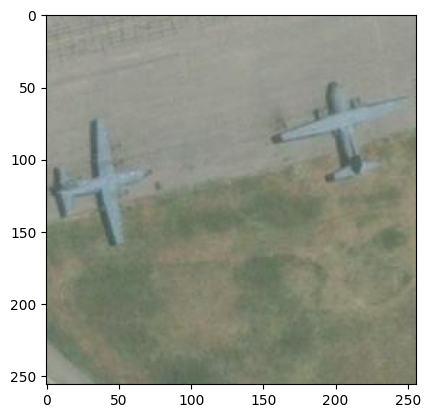

In [13]:
import cv2 
import matplotlib.pyplot as plt

image = cv2.imread(images[0])

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

We are going to use **selective search** for posposing regions. 
- After this each proposed region is passed to CNN which creates a feature map 
- Now this feature map gets passed to object probability detection.

In [14]:
# Run Selective Search
import selectivesearch
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

_, regions = selectivesearch.selective_search(img_rgb, scale=500, sigma=0.9, min_size=10)

print(f"Total proposed regions: {len(regions)}")

Total proposed regions: 31


/Users/umesh/Desktop/Computer-Vision-/myenv/lib/python3.11/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


In [16]:
regions[0]

{'rect': (0, 0, 255, 255), 'size': 60509, 'labels': [np.float64(0.0)]}

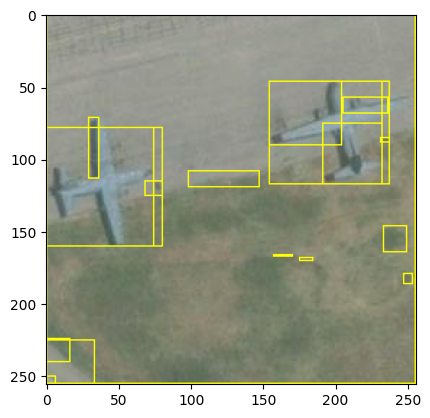

In [21]:
# Draw first 100 region proposals
for region in regions[:300]:
    x, y, w, h = region['rect']
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 255, 0), 1)
plt.imshow(img_rgb)
plt.show()

### Step3

Now we need to pass this region of proposals through a CNN to create a feature vector 

In [27]:
import pandas as pd 
import numpy as np 

df = pd.read_csv('/Users/umesh/Desktop/Computer-Vision-/Object_Detection/Airplane_dataset/Airplanes_Annotations/Airplanes_Annotations/42845.csv')

df.head()

,4
0,15 69 40 96
1,10 173 42 203
2,74 212 100 243
3,233 197 256 226


In [66]:
df.iloc[0][0]

/var/folders/g1/59v3z_793_g5rymttcvqyfcm0000gn/T/ipykernel_43870/2900375399.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][0]


'15 69 40 96'

In [110]:
# functions to parse annotation files and get bounding boxes 
import pandas as pd

def parse_annotation(annotation_file_path):
    df = pd.read_csv(annotation_file_path)
    bounding_boxes = []
    label = df.columns[0]

    for index, row in df.iterrows():
        values = row.iloc[0].strip().split(' ')
        for i in range(len(values)):
            values[i] = int(values[i])

        bounding_box = values[:4]
        bounding_boxes.append(bounding_box)

    return label, bounding_boxes
    

In [111]:
## testing parse annotation function 

parse_annotation('/Users/umesh/Desktop/Computer-Vision-/Object_Detection/Airplane_dataset/Airplanes_Annotations/Airplanes_Annotations/42845.csv')

('4',
 [[15, 69, 40, 96],
  [10, 173, 42, 203],
  [74, 212, 100, 243],
  [233, 197, 256, 226]])

In [ ]:
from torch.utils.data import Dataset, DataLoader 
from PIL import Image 

# if root directory 
class AirplaneDataset(Dataset):
    def __init__(self, images, annotations, transform=None):
        self.images = images 
        self.annotations = annotations 

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        label, boxes = parse_annotation(self.annotations[idx])
        target = {
            'label' : label,
            'boxes' : boxes
        }
        return image, target
    
# creating dataset 
dataset = AirplaneDataset(images, annotations)
print(f"Total number of samples in dataset : {len(dataset)}")

Total number of samples in dataset : 733


(<PIL.Image.Image image mode=RGB size=256x256>,
 {'label': '1', 'boxes': [[142, 36, 187, 81]]})